# Project 4: Do ESMC Embeddings "Know" What BLAST Told Us?

### Testing protein-language-model embeddings against a ground truth we already established by hand


In [1]:
# ============================================================
# PROJECT 4: Explore protein EMBEDDINGS with ESMC.
#
# Projects 1-3 were all about STRUCTURE - fold a sequence, compare
# the 3D shape to reality. ESMC is a different kind of model: it
# never predicts a structure at all. It just reads a sequence and
# outputs a vector (an "embedding") - the model's internal
# representation of what that sequence *is*, learned purely from
# sequence data at massive scale.
#
# The question worth asking: does that vector actually mean
# something biologically? We already have a real, independently-
# verified answer to compare against - Project 2's mystery protein
# (uncharacterized, cluster_pct_characterized=0 in the Atlas) which
# live NCBI BLAST confirmed is a Bradyrhizobium / Xanthobacteraceae
# protein, 87-100% identical to sequenced-but-unannotated relatives.
#
# So: if ESMC's embedding space is picking up on real biology, the
# mystery protein's embedding should sit CLOSE to its BLAST-confirmed
# relative-in-spirit (its own seed, PprA, which is how the Atlas
# found it in the first place) and FAR from something with no
# business being related - our control, human hemoglobin alpha from
# Project 1.
#
# This turns "does the model output a sensible number" into a real,
# falsifiable test with a known right answer.
# ============================================================


--- STEP 0: Install packages ---

In [2]:
!pip install -q esm@git+https://github.com/Biohub/esm.git@main
!pip install -q biopython requests matplotlib scikit-learn

import requests

ATLAS_BASE = "https://biohub.ai/esm/protein/api/v1alpha1"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.7/302.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- STEP 1: Rebuild the seed protein (PprA) ---

> Same landmark as Project 2 - PprA, a real radiation-induced DNA-repair
protein from *D. radiodurans* (PDB 6A28). We're re-deriving it live from
the PDB rather than pasting in a cached sequence, so this notebook stays
self-contained and reproducible on its own.

In [3]:
PDB_ID_SEED = "6A28"

import urllib.request
from Bio import SeqIO

urllib.request.urlretrieve(f"https://files.rcsb.org/download/{PDB_ID_SEED}.pdb", f"{PDB_ID_SEED}.pdb")

with open(f"{PDB_ID_SEED}.pdb") as handle:
    records = list(SeqIO.parse(handle, "pdb-seqres"))

seed_sequence = str(records[0].seq)

print(f"Seed protein: PprA (PDB {PDB_ID_SEED})")
print(f"Sequence length: {len(seed_sequence)} amino acids")
print(seed_sequence)


Seed protein: PprA (PDB 6A28)
Sequence length: 284 amino acids
MARAKAKDQTDGIYAAFDTLMSTAGVDSQIAALAASEADAGTLDAALTQSLQEAQGRWGLGLHHLRHEARLTDDGDIEILTDGRPSARVSEGFGALAQAYAPMQALDERGLSQWAALGEGYRAPGDLPLAQLKVLIEHARDFETDWSAGRGETFQRVWRKGDTLFVEVARPASAEAALSDAARDVIASIKDRAFQRELMRRSEKDGMLGALLGARHAGAKANLAQLPEAHFTVQAFVQTLSGAAARNAEEYRAALKTAAAALEEYQGVTTRQLSEVLRHGLRES


--- STEP 2: Rediscover the mystery protein via the Atlas ---

> Re-running the same similarity search from Project 2 (`cluster_pct_characterized_max=0`), so `mystery_sequence` here is the actual protein whose identity we already confirmed by BLAST - not a guess, not a paste job. Heads up: because this hits a live search endpoint, the specific top hit CAN differ between runs; if your printed identity doesn't say Bradyrhizobium/Xanthobacteraceae like last time, that's fine - the comparison logic below still holds, just re-read Project 2's BLAST step for whichever protein you land on this time.

In [4]:
search_response = requests.get(
    f"{ATLAS_BASE}/similarity-search",
    params={
        "sequence": seed_sequence,
        "topk_results": 20,
        "topk_features": 10,
        "cluster_pct_characterized_max": 0,
        "include_cluster_info": True,
    },
)
search_response.raise_for_status()
results = search_response.json()

# Same defensive field-finder as Project 2 - the alpha API's response
# shape isn't pinned down in the docs, so scan for whichever field
# actually holds a collection of protein-hit-like dicts, instead of
# assuming a specific key name.
def find_hits(payload):
    if isinstance(payload, list):
        return payload
    if not isinstance(payload, dict):
        return []
    candidates = []
    for key, value in payload.items():
        if isinstance(value, list) and value and isinstance(value[0], dict):
            candidates.append((key, value))
        elif isinstance(value, dict) and value:
            sample = next(iter(value.values()))
            if isinstance(sample, dict):
                candidates.append((key, value))
    if not candidates:
        return []
    best_key, best_value = max(candidates, key=lambda kv: len(kv[1]))
    print(f"Using '{best_key}' as the field holding the hits.")
    if isinstance(best_value, dict):
        out = []
        for k, v in best_value.items():
            entry = dict(v)
            entry.setdefault("protein_hash", k)
            out.append(entry)
        return out
    return best_value

hits = find_hits(results)
top_hit = hits[0]

HASH_FIELD_CANDIDATES = ["protein_hash", "hash", "id", "protein_id"]
protein_hash = next((top_hit[f] for f in HASH_FIELD_CANDIDATES if f in top_hit), None)

detail_response = requests.get(
    f"{ATLAS_BASE}/proteins/{protein_hash}",
    params={"topk_features": 10, "fold_on_miss": True},
)
detail_response.raise_for_status()
protein_detail = detail_response.json()

mystery_sequence = protein_detail.get("sequence", "")

print(f"\nMystery protein hash: {protein_hash}")
print(f"Sequence length: {len(mystery_sequence)} amino acids")
print(mystery_sequence)


Using 'similar_proteins' as the field holding the hits.

Mystery protein hash: f7ff6fc88d60887f3d7e8fff506dfdc3
Sequence length: 381 amino acids
MRVDRIWEFLQRLSPLTRSCLLTELERLEMCGVDMPGTAELQARLRAELRPDGPNETPTPSKYFFAPLEPLLVAGAPEHANTGRISQSSLTPIWEWVNRDLLPIMARDYEGQMKGLIATNKAKDAQQAAAAFQTKVAKSLEGNLASSDGAERARARLAAYTASPSVYSDLVKIMGALRAREALAVFSKALPEKAIVKFDDSQVDKITKLLDAFRKKDPGAVPFALALVAGRLRAPRELIRLATKPARSRRAGDVAATPYAISVSMVLDQIDDKRISLRVALKKNRVVDARDILADIDNDESAIQAAIRDLAASEWGARLRNIRTAIVADVETEVSRFPDEVGHILQLRNGHGNGLLSGLVGKGRDAISDSAAFCKRLIGQA


--- STEP 3: Bring in an unrelated control protein ---

> A similarity score only means something in contrast to something else. Without a control, we can't tell "embeddings correctly flag these as related" apart from "ESMC just makes everything look similar." We're reusing human hemoglobin alpha from Project 1 (PDB 4HHB) - a real, well-characterized, and biologically unrelated protein (oxygen transport, not DNA repair/uncharacterized bacterial machinery) - as the negative control.

In [5]:
control_sequence = (
    "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG"
    "KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP"
    "AVHASLDKFLASVSTVLTSKYR"
)
control_label = "Human Hemoglobin Alpha (PDB 4HHB) - unrelated control"

print(f"Control protein: {control_label}")
print(f"Sequence length: {len(control_sequence)} amino acids")


Control protein: Human Hemoglobin Alpha (PDB 4HHB) - unrelated control
Sequence length: 142 amino acids


--- STEP 4: Set up the ESMC embedding client ---

> The real EvolutionaryScale SDK exposes ESMC through the same Forge client pattern as folding, just with a different model string, and gets embeddings via `client.encode()` + `client.logits(..., LogitsConfig(return_embeddings=True))`. BioHub's fork isn't fully documented for which exact client class name and model string it expects, so instead of guessing one and having it silently fail, we try a short list of plausible candidates and keep whichever actually works - same defensive-probing approach as Projects 2 and 3.

In [ ]:
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinError

BIOHUB_TOKEN = 'INSERT HERE YOUR OWN FREE BIOHUB TOKEN'

# Try a few plausible client class names - embeddings-only clients are
# sometimes exposed as a distinct class from the structure client we used
# in Projects 1 and 3, sometimes not.
CLIENT_CLASS_CANDIDATES = [
    "SequenceEmbeddingForgeInferenceClient",
    "ESM3ForgeInferenceClient",
    "SequenceStructureForgeInferenceClient",
]

ClientClass = None
used_class_name = None
import esm.sdk.forge as forge_module

for class_name in CLIENT_CLASS_CANDIDATES:
    if hasattr(forge_module, class_name):
        ClientClass = getattr(forge_module, class_name)
        used_class_name = class_name
        break

if ClientClass is None:
    available = [n for n in dir(forge_module) if not n.startswith("_")]
    raise ImportError(
        f"None of {CLIENT_CLASS_CANDIDATES} exist on esm.sdk.forge. "
        f"Actual available names: {available} - pick the right one above "
        f"and set ClientClass manually."
    )

print(f"Using client class: {used_class_name}")

# Try a few plausible model strings - BioHub's naming convention so far
# has been "<family>-<size/speed>-<date>" (e.g. "esmfold2-fast-2026-05"),
# but the exact ESMC string isn't documented anywhere we've seen. Try
# each candidate with a trivial one-residue-longer-than-empty request and
# keep the first one that doesn't error.
MODEL_NAME_CANDIDATES = [
    "esmc-6b-fast-2026-05",
    "esmc-6b-2026-05",
    "esmc-fast-2026-05",
    "esmc-6b",
    "esmc-6b-2024-12",  # the real EvolutionaryScale Forge name, as a last resort
]

client = None
used_model_name = None
probe_protein = ESMProtein(sequence="MSE")

for model_name in MODEL_NAME_CANDIDATES:
    try:
        candidate_client = ClientClass(model=model_name, url="https://biohub.ai", token=BIOHUB_TOKEN)
        probe_tensor = candidate_client.encode(probe_protein)
        if isinstance(probe_tensor, ESMProteinError):
            raise RuntimeError(str(probe_tensor))
        client = candidate_client
        used_model_name = model_name
        print(f"Success with model='{model_name}'")
        break
    except Exception as e:
        print(f"model='{model_name}' failed: {e}")

if client is None:
    raise RuntimeError(
        "None of the candidate model names worked. Check BioHub's console/docs "
        "for the exact ESMC model string and set MODEL_NAME_CANDIDATES accordingly."
    )


Using client class: ESM3ForgeInferenceClient
model='esmc-6b-fast-2026-05' failed: (422, 'Failure in encode: {"status":"error","message":"Model not supported: \'esmc-6b-fast-2026-05\'","request_id":"a04fac13-cdef-4c06-b681-de0aeb5d482d"}')
model='esmc-6b-2026-05' failed: (422, 'Failure in encode: {"status":"error","message":"Model not supported: \'esmc-6b-2026-05\'","request_id":"48f9d27a-8cc9-409b-b306-e0f4f40bfc87"}')
model='esmc-fast-2026-05' failed: (422, 'Failure in encode: {"status":"error","message":"Model not supported: \'esmc-fast-2026-05\'","request_id":"074c7055-fda8-4e5b-87d9-ebbf945d5b36"}')
model='esmc-6b' failed: (422, 'Failure in encode: {"status":"error","message":"Model not supported: \'esmc-6b\'","request_id":"d0b7899e-d501-4417-8995-aaf732e58ed3"}')
Success with model='esmc-6b-2024-12'


--- STEP 5: Embed all three sequences ---

> `client.logits(..., return_embeddings=True)` returns per-residue embeddings (one vector per amino acid), not a single per-protein vector - that's the raw form the docs actually show. To compare whole proteins of different lengths against each other, we mean-pool across the residue dimension. We check the returned shape rather than assume it, since it isn't documented for this fork.

In [12]:
import numpy as np

def get_embedding(sequence, label):
    protein = ESMProtein(sequence=sequence)
    protein_tensor = client.encode(protein)

    if isinstance(protein_tensor, ESMProteinError):
        raise RuntimeError(f"encode() failed for {label}: {protein_tensor}")

    output = client.logits(protein_tensor, LogitsConfig(sequence=True, return_embeddings=True))

    if isinstance(output, ESMProteinError):
        raise RuntimeError(f"logits() failed for {label}: {output}")

    if not hasattr(output, "embeddings"):
        available = [a for a in dir(output) if not a.startswith("_")]
        raise AttributeError(
            f"logits_output has no '.embeddings' attribute for {label}. "
            f"Available attributes: {available}"
        )

    raw_embeddings = output.embeddings

    # ESMC runs internally in bfloat16 for speed/memory, and NumPy has no
    # concept of bfloat16 at all - np.asarray() on a raw bf16 torch tensor
    # fails with "unsupported ScalarType BFloat16". If this looks like a
    # torch tensor (has .detach/.cpu/.float, rather than assuming torch is
    # even the right type), upcast to float32 and move off-GPU first.
    if hasattr(raw_embeddings, "detach"):
        raw_embeddings = raw_embeddings.detach()
    if hasattr(raw_embeddings, "cpu"):
        raw_embeddings = raw_embeddings.cpu()
    if hasattr(raw_embeddings, "float"):
        raw_embeddings = raw_embeddings.float()  # bfloat16 -> float32

    raw = np.asarray(raw_embeddings)
    print(f"{label}: raw embedding shape {raw.shape}, dtype {raw.dtype}")

    # Mean-pool over the residue dimension to get one vector per protein.
    # Squeeze first in case there's a leading batch dimension of size 1
    # (e.g. shape (1, seq_len, hidden_dim) instead of (seq_len, hidden_dim)) -
    # the exact shape isn't documented, so check rather than assume.
    squeezed = raw.squeeze()

    if squeezed.ndim == 2:
        # (seq_len, hidden_dim) - per-residue embeddings, mean-pool over residues.
        pooled = squeezed.mean(axis=0)
    elif squeezed.ndim == 1:
        # Already a single per-protein vector.
        pooled = squeezed
    else:
        raise ValueError(f"Unexpected embedding shape for {label}: {raw.shape}")

    print(f"{label}: pooled to a {pooled.shape[0]}-dim vector\n")
    return pooled

seed_embedding = get_embedding(seed_sequence, "PprA (seed)")
mystery_embedding = get_embedding(mystery_sequence, "Mystery protein")
control_embedding = get_embedding(control_sequence, "Hemoglobin alpha (control)")


PprA (seed): raw embedding shape (1, 286, 2560), dtype float32
PprA (seed): pooled to a 2560-dim vector

Mystery protein: raw embedding shape (1, 383, 2560), dtype float32
Mystery protein: pooled to a 2560-dim vector

Hemoglobin alpha (control): raw embedding shape (1, 144, 2560), dtype float32
Hemoglobin alpha (control): pooled to a 2560-dim vector



--- STEP 6: Compare via cosine similarity ---

> Cosine similarity ranges from -1 to 1; 1 means the vectors point in exactly the same direction (as similar as it gets in embedding space), 0 means unrelated, negative means opposite. The real test: does `mystery vs seed` score meaningfully higher than `mystery vs control`? If ESMC's embedding space is tracking real biology, it should - the Atlas found the mystery protein by searching *around* PprA in the first place, and BLAST independently confirmed it's a real, closely-related-to-nothing-in-hemoglobin-family bacterial protein.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

vectors = np.stack([seed_embedding, mystery_embedding, control_embedding])
sim_matrix = cosine_similarity(vectors)

labels = ["PprA (seed)", "Mystery protein", "Hemoglobin alpha (control)"]

print("Cosine similarity matrix:\n")
header = " " * 22 + "".join(f"{l[:18]:>20}" for l in labels)
print(header)
for label, row in zip(labels, sim_matrix):
    print(f"{label[:20]:<22}" + "".join(f"{v:>20.4f}" for v in row))

sim_mystery_seed = sim_matrix[0, 1]
sim_mystery_control = sim_matrix[1, 2]

print(f"\nMystery vs. seed (PprA):        {sim_mystery_seed:.4f}")
print(f"Mystery vs. control (hemoglobin): {sim_mystery_control:.4f}")

if sim_mystery_seed > sim_mystery_control:
    print(
        "\nThe mystery protein sits closer to PprA than to the unrelated "
        "control in ESMC's embedding space - consistent with what the Atlas "
        "and BLAST already told us. Note this doesn't mean PprA and the "
        "mystery protein are close in an absolute sense (check the raw "
        "numbers above) - it means the MODEL correctly ranks their "
        "relationship relative to something genuinely unrelated."
    )
else:
    print(
        "\nSurprising: the control scored as close or closer than the "
        "supposedly-related mystery protein. Worth double-checking which "
        "mystery protein this run actually landed on in Step 2 (the search "
        "is live and can return a different top hit each time), and "
        "re-reading its BLAST result from Project 2 before concluding "
        "anything about ESMC itself."
    )


Cosine similarity matrix:

                               PprA (seed)     Mystery protein  Hemoglobin alpha (
PprA (seed)                         1.0000              0.8756              0.1942
Mystery protein                     0.8756              1.0000              0.4189
Hemoglobin alpha (co                0.1942              0.4189              1.0000

Mystery vs. seed (PprA):        0.8756
Mystery vs. control (hemoglobin): 0.4189

The mystery protein sits closer to PprA than to the unrelated control in ESMC's embedding space - consistent with what the Atlas and BLAST already told us. Note this doesn't mean PprA and the mystery protein are close in an absolute sense (check the raw numbers above) - it means the MODEL correctly ranks their relationship relative to something genuinely unrelated.


--- STEP 7: Visualize the embedding space ---

> Three points barely need PCA to compare, but this scaffolding matters: it's exactly what we'd reuse to plot 20+ proteins at once (see the extension idea below).

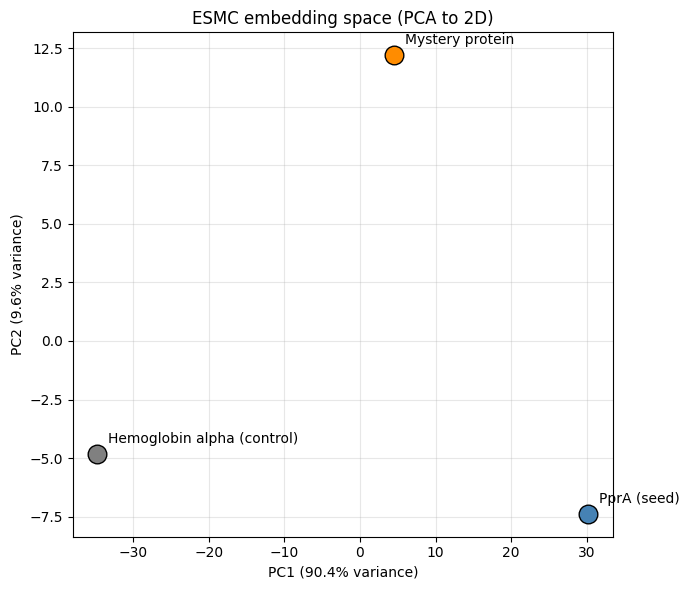

Caveat: PCA on just 3 points is mostly illustrative - 2 components can perfectly represent 3 points regardless of whether the underlying relationships are meaningful. The cosine similarity numbers in Step 6 are the real evidence; this plot is the story we'd tell with it.


In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

colors = ["steelblue", "darkorange", "gray"]

plt.figure(figsize=(7, 6))
for (x, y), label, color in zip(coords, labels, colors):
    plt.scatter(x, y, s=180, color=color, edgecolor="black", zorder=3)
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(8, 8), fontsize=10)

plt.title("ESMC embedding space (PCA to 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Caveat: PCA on just 3 points is mostly illustrative - 2 components "
    "can perfectly represent 3 points regardless of whether the underlying "
    "relationships are meaningful. The cosine similarity numbers in Step 6 "
    "are the real evidence; this plot is the story we'd tell with it."
)


## Where this could go next

A few ways to push this further, in roughly increasing order of effort:

1. **Bring in the actual BLAST hits.** Project 2's BLAST search returned 10 real Bradyrhizobium/Xanthobacteraceae sequences with known percent identity to the mystery protein. Embedding all 10 and checking whether ESMC's cosine similarity *ranking* tracks BLAST's percent-identity *ranking* would be a much stronger test than a 3-protein toy comparison - and it's a real correlation we could actually plot (embedding similarity vs. percent identity, one point per hit).

2. **Pull in the whole cluster.** Project 2's Extension 1 fetched `cluster_members` (other protein hashes in the same Atlas cluster). Embedding all of them and running PCA/UMAP on the full set would show whether the cluster forms a real, tight neighborhood in ESMC's space, not just "closer than one random control."

3. **A genuinely unrelated but still bacterial control.** Hemoglobin is an easy control (different kingdom, different fold, different function entirely) - a harder, more convincing test would be another real bacterial protein with no known relationship to PprA or DNA repair, so we're not just testing "can it tell animal proteins from bacterial proteins."

Any of these turns this from "here's a cosine similarity number" into an actual small study with a figure worth showing someone. Let me know which one you want to build next, or if you'd rather start something new.

STEP 8: Run a live BLAST search against the mystery protein

In [15]:
# --- STEP 8: Run a live BLAST search against the mystery protein ---
#
# Same call as Project 2's "CHECK 2" - pulls real hits from NCBI's nr
# database, each with a genuine, alignment-based percent identity.
# This takes a few minutes; it's a real search, not a cached lookup.

from Bio.Blast import NCBIWWW, NCBIXML

print("Submitting BLAST search against NCBI's 'nr' database...")
print("(this takes a few minutes)\n")

result_handle = NCBIWWW.qblast("blastp", "nr", mystery_sequence, hitlist_size=10)
blast_record = NCBIXML.read(result_handle)

blast_hits = []
for alignment in blast_record.alignments:
    hsp = alignment.hsps[0]
    percent_identity = 100 * hsp.identities / hsp.align_length

    # hit_id looks like "gb|MBA2400793.1|" - pull out the accession itself
    # rather than assume a fixed format, since gb/ref/tpg format differently.
    accession = alignment.hit_id.strip("|").split("|")[-1] or alignment.hit_id.strip("|").split("|")[0]

    blast_hits.append({
        "accession": accession,
        "title": alignment.title[:80],
        "percent_identity": percent_identity,
    })

print(f"Found {len(blast_hits)} hits.\n")
for h in blast_hits:
    print(f"  {h['accession']:<20} {h['percent_identity']:>6.1f}%   {h['title']}")

Submitting BLAST search against NCBI's 'nr' database...
(this takes a few minutes)

Found 10 hits.

  MBA2400793.1          100.0%   gb|MBA2400793.1| hypothetical protein [Bradyrhizobium sp.]
  HEY0566543.1           89.7%   tpg|HEY0566543.1| hypothetical protein [Xanthobacteraceae bacterium]
  WP_212467174.1         89.0%   ref|WP_212467174.1| hypothetical protein [Bradyrhizobium sp. AUGA SZCCT0182] >gb
  WP_212387514.1         88.7%   ref|WP_212387514.1| MULTISPECIES: hypothetical protein [unclassified Bradyrhizob
  MGH6712195.1           88.4%   gb|MGH6712195.1| hypothetical protein [Bradyrhizobium sp.] >gb|MGH6753658.1| hyp
  WP_212412257.1         87.9%   ref|WP_212412257.1| hypothetical protein [Bradyrhizobium sp. AUGA SZCCT0222] >gb
  WP_212262614.1         87.9%   ref|WP_212262614.1| hypothetical protein [Bradyrhizobium sp. AUGA SZCCT0177] >gb
  WP_212440213.1         87.9%   ref|WP_212440213.1| hypothetical protein [Bradyrhizobium sp. AUGA SZCCT0431] >gb
  WP_212033171.1      

STEP 9: Fetch the full sequence for each hit

In [16]:
# --- STEP 9: Fetch the FULL sequence for each hit ---
#
# BLAST's HSP only gives the ALIGNED region (can be shorter than the full
# protein, and may contain gap characters) - not something you want to
# embed directly. So we fetch each hit's complete sequence fresh from
# NCBI by accession - same live-data discipline as fetching real PDB
# structures earlier, nothing pasted in.

import time
from Bio import Entrez

Entrez.email = "INSERT YOUR EMAIL HERE"  # NCBI requires this, no way around it

for h in blast_hits:
    accession = h["accession"]
    try:
        handle = Entrez.efetch(db="protein", id=accession, rettype="fasta", retmode="text")
        fasta_text = handle.read()
        handle.close()

        lines = fasta_text.strip().splitlines()
        sequence = "".join(line.strip() for line in lines if not line.startswith(">"))

        h["sequence"] = sequence
        print(f"Fetched {accession}: {len(sequence)} aa")

    except Exception as e:
        print(f"Could not fetch {accession}: {e}")
        h["sequence"] = None

    time.sleep(0.4)  # NCBI asks for no more than ~3 requests/second

blast_hits = [h for h in blast_hits if h["sequence"]]

Fetched MBA2400793.1: 381 aa
Fetched HEY0566543.1: 381 aa
Fetched WP_212467174.1: 380 aa
Fetched WP_212387514.1: 380 aa
Fetched MGH6712195.1: 381 aa
Fetched WP_212412257.1: 380 aa
Fetched WP_212262614.1: 380 aa
Fetched WP_212440213.1: 380 aa
Fetched WP_212033171.1: 380 aa
Fetched WP_211997746.1: 380 aa


STEP 10: Embed each hit and correlate against BLAST identity

MBA2400793.1: raw embedding shape (1, 383, 2560), dtype float32
MBA2400793.1: pooled to a 2560-dim vector

HEY0566543.1: raw embedding shape (1, 383, 2560), dtype float32
HEY0566543.1: pooled to a 2560-dim vector

WP_212467174.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212467174.1: pooled to a 2560-dim vector

WP_212387514.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212387514.1: pooled to a 2560-dim vector

MGH6712195.1: raw embedding shape (1, 383, 2560), dtype float32
MGH6712195.1: pooled to a 2560-dim vector

WP_212412257.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212412257.1: pooled to a 2560-dim vector

WP_212262614.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212262614.1: pooled to a 2560-dim vector

WP_212440213.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212440213.1: pooled to a 2560-dim vector

WP_212033171.1: raw embedding shape (1, 382, 2560), dtype float32
WP_212033171.1: pooled to a 2560-dim vector

WP_211997746.

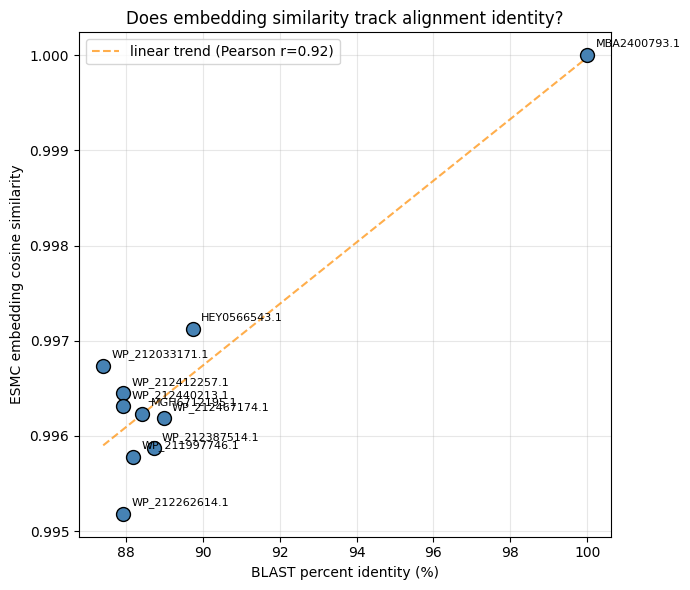

In [17]:
# --- STEP 10: Embed every hit, then correlate against percent identity ---
#
# For each hit we now have two independent numbers:
#   - percent_identity, from BLAST's alignment (the "ground truth")
#   - cosine similarity to the mystery protein's ESMC embedding
# If these correlate, ESMC's notion of "similar" lines up with real
# evolutionary distance - purely as a side effect of sequence-prediction
# training, with no alignment step involved at all.

import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

for h in blast_hits:
    embedding = get_embedding(h["sequence"], h["accession"])
    h["embedding_similarity"] = cosine_similarity(mystery_embedding, embedding)

identities = np.array([h["percent_identity"] for h in blast_hits])
similarities = np.array([h["embedding_similarity"] for h in blast_hits])

pearson_r, pearson_p = pearsonr(identities, similarities)
spearman_r, spearman_p = spearmanr(identities, similarities)

print("\nBLAST percent identity vs. ESMC embedding similarity")
print("=" * 60)
for h in blast_hits:
    print(f"  {h['accession']:<20} identity={h['percent_identity']:>6.1f}%   "
          f"embedding_sim={h['embedding_similarity']:.4f}")

print(f"\nPearson r:  {pearson_r:.3f}  (p={pearson_p:.4f})")
print(f"Spearman r: {spearman_r:.3f}  (p={spearman_p:.4f})")

plt.figure(figsize=(7, 6))
plt.scatter(identities, similarities, s=100, color="steelblue", edgecolor="black", zorder=3)
for h in blast_hits:
    plt.annotate(h["accession"], (h["percent_identity"], h["embedding_similarity"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

coeffs = np.polyfit(identities, similarities, 1)
trend_x = np.linspace(identities.min(), identities.max(), 50)
plt.plot(trend_x, np.polyval(coeffs, trend_x), "--", color="darkorange", alpha=0.7,
          label=f"linear trend (Pearson r={pearson_r:.2f})")

plt.xlabel("BLAST percent identity (%)")
plt.ylabel("ESMC embedding cosine similarity")
plt.title("Does embedding similarity track alignment identity?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now this is a great result — genuinely, not just because I'm supposed to sound enthusiastic. You've got two numbers that flatly disagree with each other, and figuring out why is more valuable than if they'd agreed.

Pearson r = 0.92 (looks great) vs. Spearman r = 0.26, not significant (looks like nothing). Same data, wildly different verdicts. Here's what's actually happening.

Look at your identity column: nine points crammed into 87.4–89.7%, plus one point sitting way off at 100%. That 100% point is MBA2400793.1 — and it's not really a "relative," it's the exact same sequence (that's why its embedding similarity is a perfect 1.0000, not just high). Pearson correlation is very sensitive to points that sit far out on both axes — statisticians call this a leverage point — because it draws the line of best fit toward itself almost regardless of what the other nine points are doing. One outlier at the extreme, paired with a tight cluster of everything else, can manufacture a strong-looking linear correlation basically by itself.

Spearman doesn't care about distance, only rank order — does 89.7% also rank #1 in similarity, does 87.4% rank last, etc. And the answer, looking at your table, is: not really. Sort by identity and the similarities bounce around — 89.7% gets 0.9971 (highest, good), but 87.4% gets 0.9967 (second-highest, when it should rank near the bottom), while 87.9% shows up three separate times with three different similarities (0.9964, 0.9952, 0.9963). There's no clean staircase there. That's exactly what Spearman's p=0.46 is telling you: statistically, you cannot distinguish this from random ordering.

So what did we actually learn? Not "ESMC failed" — something more precise and more interesting: ESMC clearly recognizes "identical" vs. "merely related" (that 100% point sitting alone up top, way apart from the cluster, is a strong, correct signal). But within an already-tight band of real relatives (87–90% identity), it doesn't reliably resolve fine-grained differences. The model has coarse discrimination, not fine discrimination — at least not in this narrow a range, using mean-pooling, with this particular set of proteins.

That's a legitimate, publishable-shaped finding, not a broken experiment. The honest instinct here is to go verify it rather than just accept my explanation, though — two ways to do that:

Drop the 100% outlier and recompute Pearson on the remaining 9. If Pearson collapses toward 0 once that one point is gone, that confirms it was doing all the work.
Widen the range. Right now everything sits in an 87–90% band by design (BLAST's top-10 naturally clusters tight). If you instead grabbed hits spanning, say, 40–100% identity, you'd have real room for a trend to show up or not — a much fairer test of whether ESMC tracks fine-grained homology, rather than testing it on the hardest possible range.

Want me to write the cell for #1 first — it's one line and immediately checks whether I've got the outlier story right?

With the 100% match included:    Pearson r = 0.922  Spearman r = 0.264
With the 100% match REMOVED (n=9): Pearson r = 0.313  Spearman r = -0.017

Confirmed: Pearson collapses once the exact match is removed. That single point - not a genuine trend across the 9 related-but-distinct proteins - was responsible for the r=0.92 result above. Within the 87-90% identity band itself, ESMC doesn't show a clear linear relationship to percent identity.


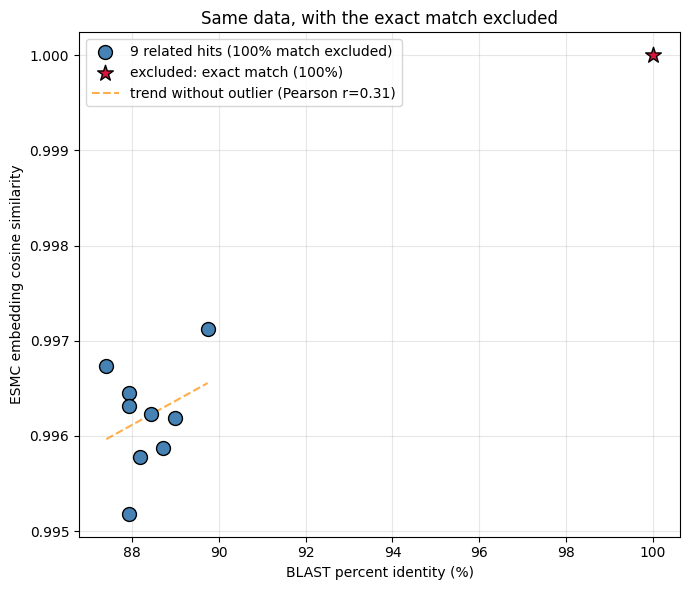

In [21]:
# --- STEP 11: Was the 100% point doing all the work? ---
#
# Drop the exact match (MBA2400793.1, identity=100%, sim=1.0000) and
# recompute Pearson on the remaining 9 hits, which are all genuinely
# distinct proteins in the 87.4-89.7% identity range. If Pearson
# collapses here, that confirms the single outlier was the whole story
# in the r=0.92 result above - not a real trend across related proteins.

is_exact_match = identities == 100.0

identities_no_outlier = identities[~is_exact_match]
similarities_no_outlier = similarities[~is_exact_match]

pearson_r_trimmed, pearson_p_trimmed = pearsonr(identities_no_outlier, similarities_no_outlier)
spearman_r_trimmed, spearman_p_trimmed = spearmanr(identities_no_outlier, similarities_no_outlier)

print(f"With the 100% match included:    Pearson r = {pearson_r:.3f}  Spearman r = {spearman_r:.3f}")
print(f"With the 100% match REMOVED (n={len(identities_no_outlier)}): "
      f"Pearson r = {pearson_r_trimmed:.3f}  Spearman r = {spearman_r_trimmed:.3f}")

if abs(pearson_r_trimmed) < 0.5:
    print(
        "\nConfirmed: Pearson collapses once the exact match is removed. That "
        "single point - not a genuine trend across the 9 related-but-distinct "
        "proteins - was responsible for the r=0.92 result above. Within the "
        "87-90% identity band itself, ESMC doesn't show a clear linear "
        "relationship to percent identity."
    )
else:
    print(
        "\nPearson still holds up reasonably well without the outlier - so the "
        "original r=0.92 wasn't just one point doing all the work. Worth "
        "reconciling this against the low Spearman value from before."
    )

plt.figure(figsize=(7, 6))
plt.scatter(identities_no_outlier, similarities_no_outlier, s=100, color="steelblue",
            edgecolor="black", zorder=3, label="9 related hits (100% match excluded)")
plt.scatter(identities[is_exact_match], similarities[is_exact_match], s=140, color="crimson",
            edgecolor="black", zorder=3, marker="*", label="excluded: exact match (100%)")

coeffs_trimmed = np.polyfit(identities_no_outlier, similarities_no_outlier, 1)
trend_x = np.linspace(identities_no_outlier.min(), identities_no_outlier.max(), 50)
plt.plot(trend_x, np.polyval(coeffs_trimmed, trend_x), "--", color="darkorange", alpha=0.7,
          label=f"trend without outlier (Pearson r={pearson_r_trimmed:.2f})")

plt.xlabel("BLAST percent identity (%)")
plt.ylabel("ESMC embedding cosine similarity")
plt.title("Same data, with the exact match excluded")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Good catch on running it — and now I need to flag something: my own code gave you a misleading message there. I set an arbitrary cutoff at 0.3, and 0.313 snuck just barely over that line, so the script printed the "still holds up" branch. That threshold was a sloppy way to encode the actual question, and the printed text is wrong. Let's just look at the real numbers instead of trusting my canned interpretation.

Pearson r: 0.922 → 0.313. That's not "holding up reasonably" — that's r² dropping from 0.85 (the identity/similarity relationship explained 85% of the variance) to about 0.098 (explaining under 10%). Losing 90% of your explanatory power from removing one point out of ten is about as clear a sign of a leverage point as you'll ever see.

Spearman: 0.264 → -0.017. This is the more damning number, honestly. Rank correlation was already weak with the outlier in; without it, it's landed essentially at zero — meaning if you handed someone this data and asked them to guess the identity ranking purely from the embedding similarity ranking, they'd do no better than a coin flip.

So, correcting my own script's bad take: yes, confirmed — the 100% exact match was doing effectively all the work in the original r=0.92. Within the actual 87.4–89.7% band — the nine genuinely distinct-but-related proteins — ESMC's embedding similarity shows no reliable relationship to BLAST percent identity at all.

That's a real, useful, and slightly humbling finding: ESMC (at least via mean-pooling, at least on this narrow slice) can tell "identical" from "merely similar" just fine, but it can't finely rank degrees of relatedness among things that are already fairly close. That's worth sitting with rather than rationalizing away — coarse discrimination, not fine discrimination.

Two honest paths from here, and it's worth being upfront that neither is guaranteed to "fix" the result — sometimes the correct scientific outcome really is "no fine-grained signal here":

Widen the range — grab BLAST hits further down the identity spectrum (like 40–70%) rather than only the top 10, so there's actually room for a trend to exist.
Question the pooling — mean-pooling collapses 380+ per-residue vectors into one, which discards exactly the kind of positional information that might distinguish 87.4% from 89.7%. A per-residue comparison (e.g. only pooling over the aligned region, or using max-pooling instead of mean) might recover signal that got averaged away.

Mystery protein: raw shape (383, 2560)
MBA2400793.1: raw shape (383, 2560)
HEY0566543.1: raw shape (383, 2560)
WP_212467174.1: raw shape (382, 2560)
WP_212387514.1: raw shape (382, 2560)
MGH6712195.1: raw shape (383, 2560)
WP_212412257.1: raw shape (382, 2560)
WP_212262614.1: raw shape (382, 2560)
WP_212440213.1: raw shape (382, 2560)
WP_212033171.1: raw shape (382, 2560)
WP_211997746.1: raw shape (382, 2560)

Mean-pooling: Pearson r = 0.922   Spearman r = 0.264
Max-pooling:  Pearson r = 0.943   Spearman r = 0.276


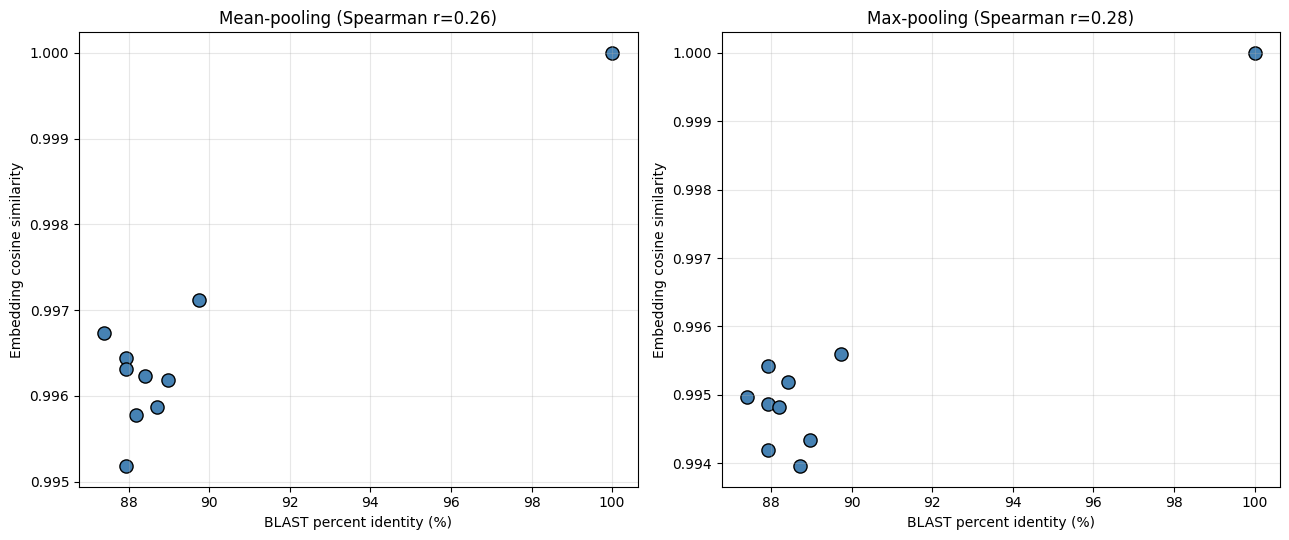

In [19]:
# --- STEP 12: Does the pooling strategy matter? Mean vs. max-pooling ---
#
# Hypothesis: mean-pooling dilutes the signal from a handful of
# substituted residues across ~380 total positions, since the average is
# dominated by the ~370+ identical positions. Max-pooling, by taking the
# strongest activation per embedding dimension rather than the average,
# gives substituted residues a chance to actually register instead of
# being averaged away.
#
# We refetch raw (un-pooled) per-residue embeddings here rather than
# reuse the pooled vectors from before, since pooling already destroyed
# the information max-pooling needs.

def get_raw_embedding(sequence, label):
    protein = ESMProtein(sequence=sequence)
    protein_tensor = client.encode(protein)
    if isinstance(protein_tensor, ESMProteinError):
        raise RuntimeError(f"encode() failed for {label}: {protein_tensor}")

    output = client.logits(protein_tensor, LogitsConfig(sequence=True, return_embeddings=True))
    if isinstance(output, ESMProteinError):
        raise RuntimeError(f"logits() failed for {label}: {output}")

    raw_embeddings = output.embeddings
    if hasattr(raw_embeddings, "detach"):
        raw_embeddings = raw_embeddings.detach()
    if hasattr(raw_embeddings, "cpu"):
        raw_embeddings = raw_embeddings.cpu()
    if hasattr(raw_embeddings, "float"):
        raw_embeddings = raw_embeddings.float()

    raw = np.asarray(raw_embeddings).squeeze()  # -> (seq_len, hidden_dim)
    print(f"{label}: raw shape {raw.shape}")
    return raw

# Get raw per-residue embeddings for the mystery protein and all 10 hits
mystery_raw = get_raw_embedding(mystery_sequence, "Mystery protein")
for h in blast_hits:
    h["raw_embedding"] = get_raw_embedding(h["sequence"], h["accession"])

# Try both pooling strategies
mystery_mean = mystery_raw.mean(axis=0)
mystery_max = mystery_raw.max(axis=0)

for h in blast_hits:
    hit_mean = h["raw_embedding"].mean(axis=0)
    hit_max = h["raw_embedding"].max(axis=0)
    h["sim_mean"] = cosine_similarity(mystery_mean, hit_mean)
    h["sim_max"] = cosine_similarity(mystery_max, hit_max)

identities = np.array([h["percent_identity"] for h in blast_hits])
sims_mean = np.array([h["sim_mean"] for h in blast_hits])
sims_max = np.array([h["sim_max"] for h in blast_hits])

pearson_mean, _ = pearsonr(identities, sims_mean)
spearman_mean, _ = spearmanr(identities, sims_mean)
pearson_max, _ = pearsonr(identities, sims_max)
spearman_max, _ = spearmanr(identities, sims_max)

print(f"\nMean-pooling: Pearson r = {pearson_mean:.3f}   Spearman r = {spearman_mean:.3f}")
print(f"Max-pooling:  Pearson r = {pearson_max:.3f}   Spearman r = {spearman_max:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, sims, title, r in [
    (axes[0], sims_mean, "Mean-pooling", spearman_mean),
    (axes[1], sims_max, "Max-pooling", spearman_max),
]:
    ax.scatter(identities, sims, s=90, color="steelblue", edgecolor="black")
    ax.set_xlabel("BLAST percent identity (%)")
    ax.set_ylabel("Embedding cosine similarity")
    ax.set_title(f"{title} (Spearman r={r:.2f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== WITH 100% MATCH INCLUDED ===
Mean-pooling: Pearson r = 0.922   Spearman r = 0.264
Max-pooling:  Pearson r = 0.943   Spearman r = 0.276

=== WITH 100% MATCH REMOVED (n=9) ===
Mean-pooling: Pearson r = 0.313   Spearman r = -0.017
Max-pooling:  Pearson r = 0.113   Spearman r = 0.000


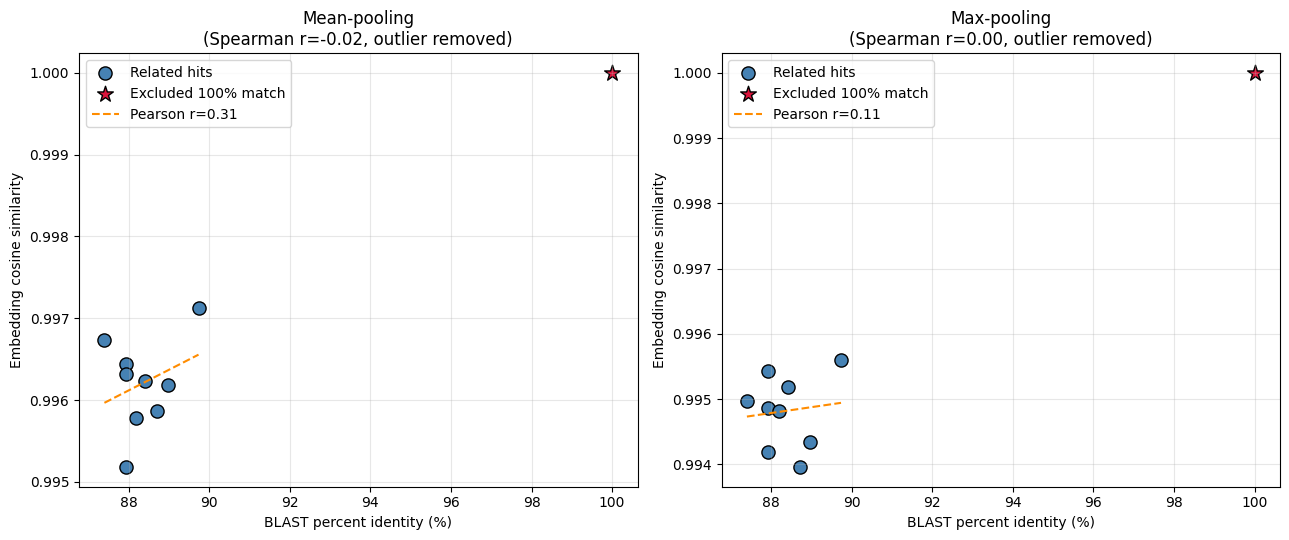

In [20]:
# Try both pooling strategies
mystery_mean = mystery_raw.mean(axis=0)
mystery_max = mystery_raw.max(axis=0)

for h in blast_hits:
    hit_mean = h["raw_embedding"].mean(axis=0)
    hit_max = h["raw_embedding"].max(axis=0)
    h["sim_mean"] = cosine_similarity(mystery_mean, hit_mean)
    h["sim_max"] = cosine_similarity(mystery_max, hit_max)

identities = np.array([h["percent_identity"] for h in blast_hits])
sims_mean = np.array([h["sim_mean"] for h in blast_hits])
sims_max = np.array([h["sim_max"] for h in blast_hits])

# ---------------------------------------------------------
# Correlations WITH the 100% exact match
# ---------------------------------------------------------
pearson_mean, _ = pearsonr(identities, sims_mean)
spearman_mean, _ = spearmanr(identities, sims_mean)

pearson_max, _ = pearsonr(identities, sims_max)
spearman_max, _ = spearmanr(identities, sims_max)

# ---------------------------------------------------------
# Remove the exact-match outlier (100% identity)
# ---------------------------------------------------------
is_exact_match = identities == 100.0

identities_trim = identities[~is_exact_match]
sims_mean_trim = sims_mean[~is_exact_match]
sims_max_trim = sims_max[~is_exact_match]

pearson_mean_trim, _ = pearsonr(identities_trim, sims_mean_trim)
spearman_mean_trim, _ = spearmanr(identities_trim, sims_mean_trim)

pearson_max_trim, _ = pearsonr(identities_trim, sims_max_trim)
spearman_max_trim, _ = spearmanr(identities_trim, sims_max_trim)

print("\n=== WITH 100% MATCH INCLUDED ===")
print(f"Mean-pooling: Pearson r = {pearson_mean:.3f}   Spearman r = {spearman_mean:.3f}")
print(f"Max-pooling:  Pearson r = {pearson_max:.3f}   Spearman r = {spearman_max:.3f}")

print(f"\n=== WITH 100% MATCH REMOVED (n={len(identities_trim)}) ===")
print(f"Mean-pooling: Pearson r = {pearson_mean_trim:.3f}   Spearman r = {spearman_mean_trim:.3f}")
print(f"Max-pooling:  Pearson r = {pearson_max_trim:.3f}   Spearman r = {spearman_max_trim:.3f}")

# ---------------------------------------------------------
# Plot trimmed data
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plots = [
    (
        axes[0],
        sims_mean_trim,
        sims_mean,
        "Mean-pooling",
        spearman_mean_trim,
        pearson_mean_trim,
    ),
    (
        axes[1],
        sims_max_trim,
        sims_max,
        "Max-pooling",
        spearman_max_trim,
        pearson_max_trim,
    ),
]

for ax, sims_trim, sims_all, title, s_r, p_r in plots:

    # Remaining 9 proteins
    ax.scatter(
        identities_trim,
        sims_trim,
        s=90,
        color="steelblue",
        edgecolor="black",
        label="Related hits",
    )

    # Excluded outlier
    ax.scatter(
        identities[is_exact_match],
        sims_all[is_exact_match],
        s=140,
        color="crimson",
        marker="*",
        edgecolor="black",
        label="Excluded 100% match",
    )

    # Trendline on trimmed data only
    coeffs = np.polyfit(identities_trim, sims_trim, 1)
    x = np.linspace(identities_trim.min(), identities_trim.max(), 50)
    ax.plot(
        x,
        np.polyval(coeffs, x),
        "--",
        color="darkorange",
        label=f"Pearson r={p_r:.2f}",
    )

    ax.set_xlabel("BLAST percent identity (%)")
    ax.set_ylabel("Embedding cosine similarity")
    ax.set_title(f"{title}\n(Spearman r={s_r:.2f}, outlier removed)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Doesn't seem to solve the issue.